In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix

df=pd.read_csv("iris.csv")
df.head(5)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [38]:
from sklearn.preprocessing import StandardScaler

C:\Users\win\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


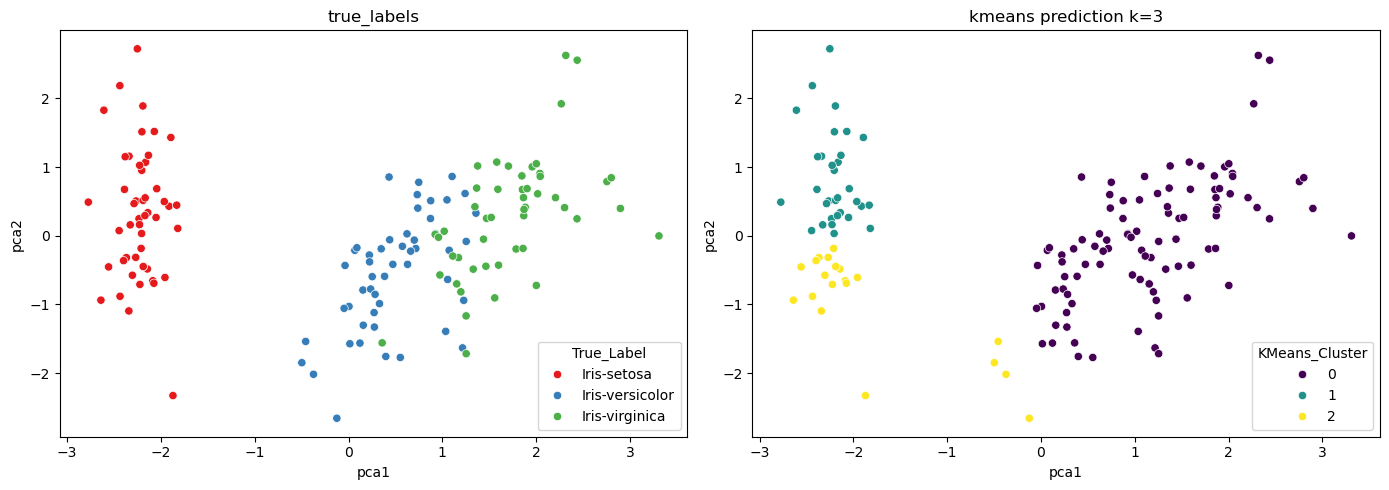

In [41]:
x=df.iloc[:,1:5]
y=df.iloc[:,5]
scaler=StandardScaler()
xscale=scaler.fit_transform(x)
kmean=KMeans(n_clusters=3,random_state=42)
ypred=kmean.fit_predict(xscale)
pca=PCA(n_components=2)
xpca=pca.fit_transform(xscale)
pcadf=pd.DataFrame(data=xpca,columns=["pca1","pca2"])
pcadf["True_Label"]=y.values
pcadf["KMeans_Cluster"]=ypred
fig,axes=plt.subplots(1,2,figsize=(14,5))
sns.scatterplot(x="pca1",y="pca2",hue="True_Label",data=pcadf,palette="Set1",ax=axes[0],)
axes[0].set_title("true_labels")
sns.scatterplot(x='pca1',y='pca2',hue="KMeans_Cluster",data=pcadf,palette="viridis",ax=axes[1],)
axes[1].set_title("kmeans prediction k=3")
plt.tight_layout()
plt.show()

In [42]:
print("comparison matrix:")
compare=pd.DataFrame({'actual species':y,'predicted species':ypred})
print(pd.crosstab(compare['actual species'],compare['predicted species']))

comparison matrix:
predicted species   0   1   2
actual species               
Iris-setosa         0  32  18
Iris-versicolor    46   0   4
Iris-virginica     50   0   0
